In [4]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("height-weight (1) - Copy.csv")
print(df.head())

   Weight  Height
0      45     120
1      58     135
2      48     123
3      60     145
4      70     160


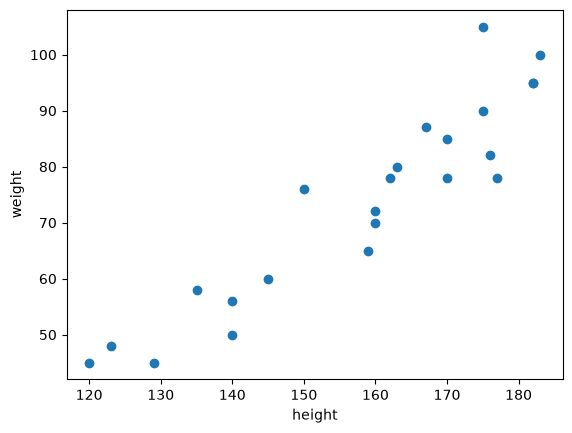

In [6]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel("height")
plt.ylabel("weight")
plt.show()

In [14]:
#steps 
#1.dataset
#2.train the datset
#3.test the model
#4.predict the output
#5.evaluate the model

X=df[['Height']]
y=df['Weight']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X.shape
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [17]:
#standardise the dataset
from sklearn.preprocessing import  StandardScaler

scaler = StandardScaler() ##applying Z_score
X_scalar=scaler.fit_transform(X_train)
X_test =scaler.transform(X_test)

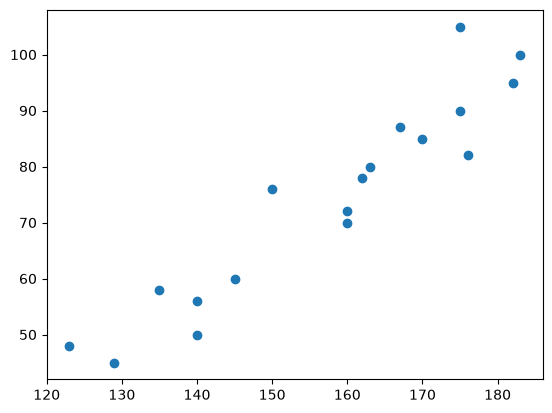

In [18]:
plt.scatter(X_train,y_train)

In [19]:
#train the model
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.93]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Height']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-71.78
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [20]:
regression.coef_

array([0.92733179])

In [21]:
regression.intercept_

np.float64(-71.77697985238385)

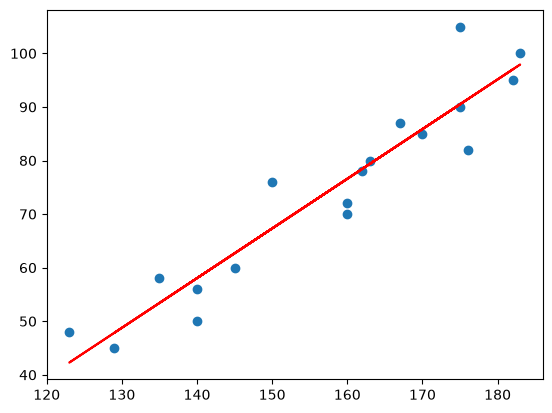

In [23]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')

In [24]:
y_pred_test=regression.predict(X_test)

c:\Users\chitrashree\myenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [25]:
y_pred_test,y_test

(array([-70.77378853, -71.13390849, -73.70619393, -70.51655999,
        -71.69981129]),
 15    78
 9     78
 0     45
 8     95
 17    65
 Name: Weight, dtype: int64)

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

r2 = r2_score(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("MAE:", mae)
print("R² Score:", r2)
print("RMSE:", rmse)

MAE: 143.7660524460464
R² Score: -74.82556812424754
RMSE: 144.60172428412636
